                  mean        std  count
state                                   
baseline    898.751773  40.576654    282
meditation  908.583333  44.816684     84
stress      953.796053  28.067879    152
ANOVA p = 5.1589494345782756e-39


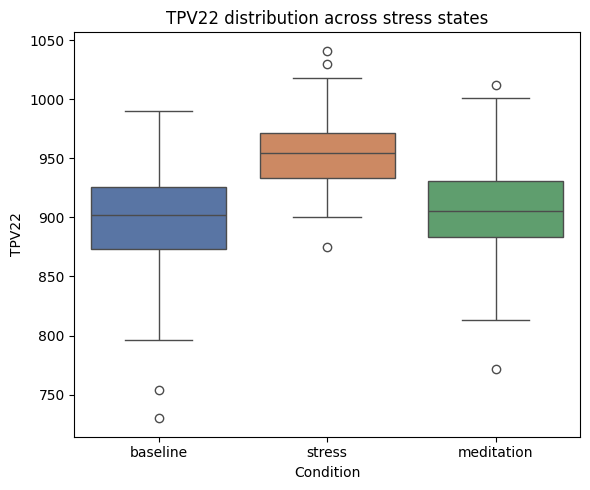

In [9]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# TPV22만 사용
data = df[["subject", "state", "TPV22"]].dropna()

# -------------------------
# Mean ± STD 계산
# -------------------------
summary = data.groupby("state")["TPV22"].agg(["mean","std","count"])
print(summary)

# -------------------------
# p-value (ANOVA)
# -------------------------
b = data[data.state=="baseline"]["TPV22"]
s = data[data.state=="stress"]["TPV22"]
m = data[data.state=="meditation"]["TPV22"]

anova = f_oneway(b,s,m)
kruskal_test = kruskal(b,s,m)

print("ANOVA p =", anova.pvalue)

# -------------------------
# Figure
# -------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    x="state",
    y="TPV22",
    data=data,
    palette=["#4C72B0","#DD8452","#55A868"]
)

plt.xlabel("Condition")
plt.ylabel("TPV22")
plt.title("TPV22 distribution across stress states")

plt.tight_layout()
plt.show()


Feature: TPV9
                mean       std  count
state                                
baseline    0.005509  0.001327    282
meditation  0.005712  0.001484     84
stress      0.006910  0.001663    152
ANOVA p = 1.9180135625324544e-19


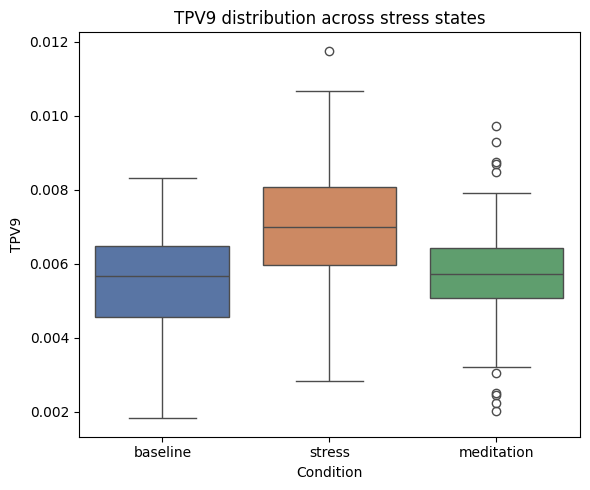


Feature: TPV4
                mean       std  count
state                                
baseline    0.006494  0.000935    282
meditation  0.006259  0.000939     84
stress      0.007397  0.001036    152
ANOVA p = 3.1329384049085664e-22


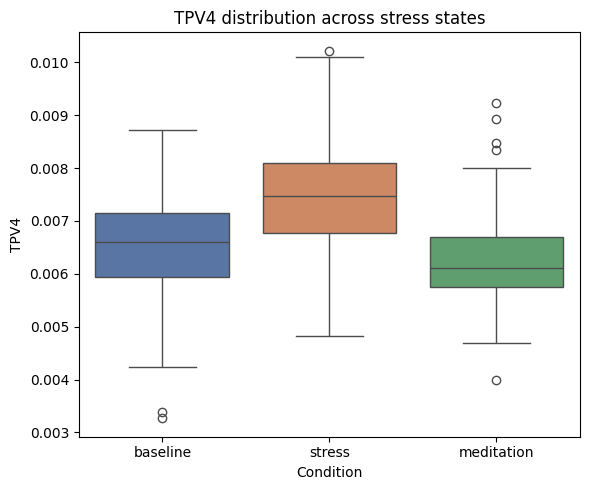


Feature: TPV2
                mean       std  count
state                                
baseline    0.041726  0.005720    282
meditation  0.038526  0.005595     84
stress      0.046419  0.004813    152
ANOVA p = 1.045838286358844e-25


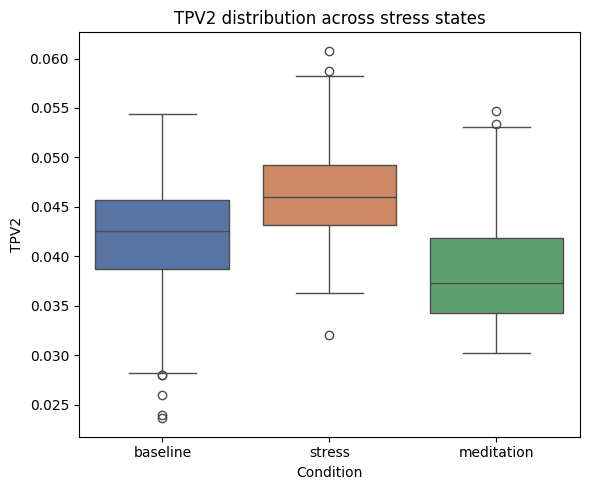


Feature: TPV0
                mean       std  count
state                                
baseline    0.035232  0.004924    282
meditation  0.032267  0.004852     84
stress      0.039022  0.003930    152
ANOVA p = 3.398801154818963e-25


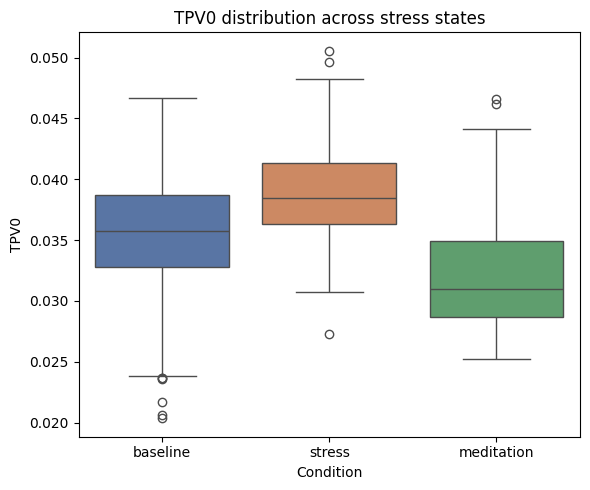


Feature: TPV28
                mean       std  count
state                                
baseline    0.008723  0.001402    282
meditation  0.007907  0.001354     84
stress      0.009519  0.001310    152
ANOVA p = 1.3582131355677366e-16


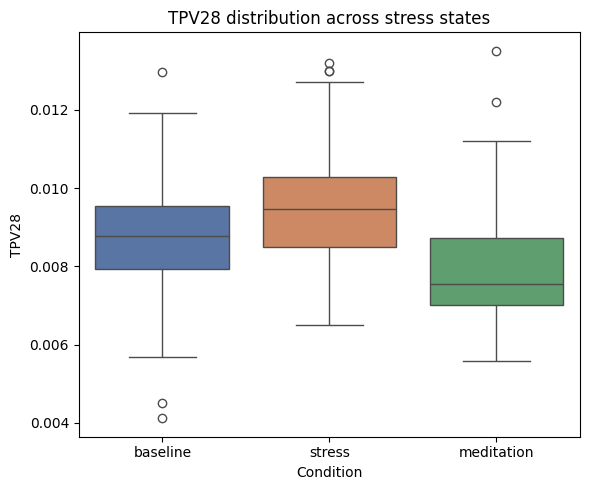


Feature: TPV8
                mean       std  count
state                                
baseline    0.002609  0.000695    282
meditation  0.002982  0.000859     84
stress      0.003303  0.000925    152
ANOVA p = 2.6972815266934495e-16


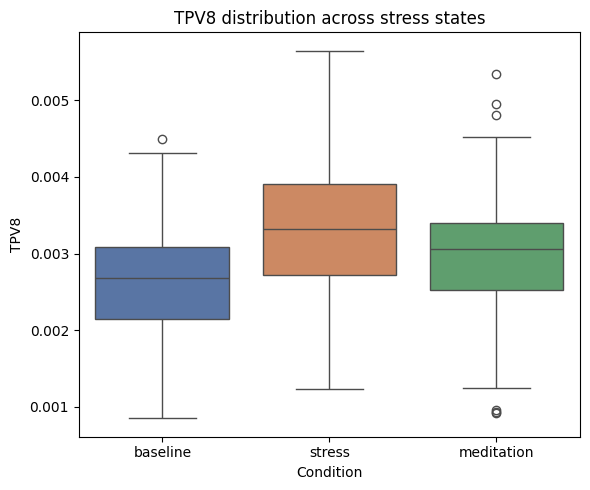


Feature: TPV19
                mean       std  count
state                                
baseline    0.021116  0.005777    282
meditation  0.023128  0.006577     84
stress      0.025585  0.007083    152
ANOVA p = 4.757507793518931e-11


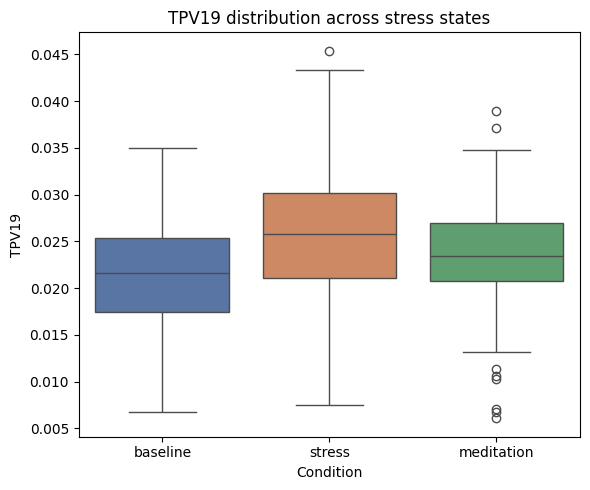


Feature: TPV14
                mean       std  count
state                                
baseline    0.017533  0.004766    282
meditation  0.018987  0.005328     84
stress      0.020980  0.005769    152
ANOVA p = 6.58164829521382e-10


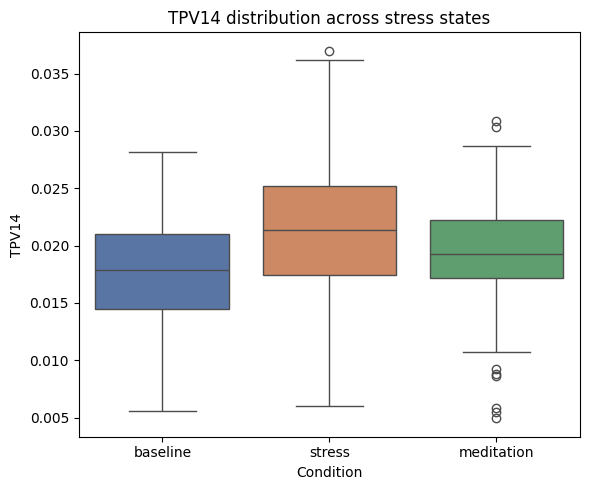


Feature: TPV26
                mean       std  count
state                                
baseline    5.839055  0.263056    282
meditation  5.965814  0.305811     84
stress      6.002106  0.255423    152
ANOVA p = 2.434152646218849e-09


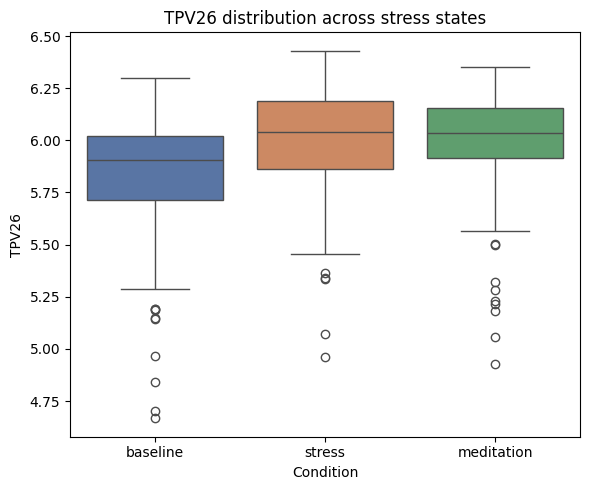


Feature: TPV11
                  mean        std  count
state                                   
baseline     95.477414  83.731069    282
meditation  115.184196  98.119935     84
stress       76.029079  78.717798    152
ANOVA p = 0.0025629139879606655


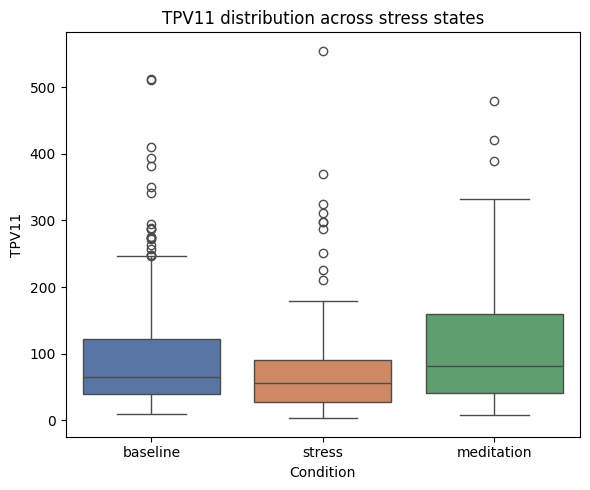


===== Statistical Test Summary =====
  feature       anova_p
0    TPV9  1.918014e-19
1    TPV4  3.132938e-22
2    TPV2  1.045838e-25
3    TPV0  3.398801e-25
4   TPV28  1.358213e-16
5    TPV8  2.697282e-16
6   TPV19  4.757508e-11
7   TPV14  6.581648e-10
8   TPV26  2.434153e-09
9   TPV11  2.562914e-03


In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# 분석할 TPV feature 리스트
tpv_features = [
    'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28',
    'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11'
]

results = []

for feature in tpv_features:

    print("\n==============================")
    print(f"Feature: {feature}")
    print("==============================")

    data = df[["subject", "state", feature]].dropna()

    # mean ± std
    summary = data.groupby("state")[feature].agg(["mean","std","count"])
    print(summary)

    # 그룹 분리
    b = data[data.state=="baseline"][feature]
    s = data[data.state=="stress"][feature]
    m = data[data.state=="meditation"][feature]

    # 통계검정
    anova = f_oneway(b,s,m)

    print("ANOVA p =", anova.pvalue)

    # 결과 저장
    results.append({
        "feature": feature,
        "anova_p": anova.pvalue,
    })

    # figure
    plt.figure(figsize=(6,5))

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        palette=["#4C72B0","#DD8452","#55A868"]
    )

    plt.xlabel("Condition")
    plt.ylabel(feature)
    plt.title(f"{feature} distribution across stress states")

    plt.tight_layout()
    plt.show()

# 결과 테이블
results_df = pd.DataFrame(results)

print("\n===== Statistical Test Summary =====")
print(results_df)